In [6]:
import sys
sys.path.insert(0,'../g3algo/')
from g3groupfinder import giantmodel, decayexp, sigmarange
import foftools as fof
import iterativecombination as ic
from smoothedbootstrap import smoothedbootstrap as sbs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
from matplotlib import rcParams
from scipy.optimize import curve_fit
from center_binned_stats import center_binned_stats
from scipy.stats import ks_2samp as kstest
from scipy.interpolate import interp1d
rcParams['axes.labelsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['font.family'] = 'sans-serif'
rcParams['grid.color'] = 'k'
rcParams['grid.linewidth'] = 0.2
my_locator = MaxNLocator(6)
singlecolsize = (3.3522420091324205, 2.0717995001590714)
doublecolsize = (7.100005949910059, 4.3880449973709)
HUBBLE_CONST = 70.

from scipy.spatial.distance import euclidean
def hellinger2(p, q):
    return euclidean(np.sqrt(p), np.sqrt(q)) / np.sqrt(2)

def decayexp_referee(x, a, b):
    return np.abs(a)*np.exp(-1*np.abs(b)*(x+19.5))#+np.abs(d)

In [7]:
%matplotlib inline
ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")
ecodata = ecodata[ecodata.absrmag<=-17.33]
ecoradeg = ecodata['radeg'].to_numpy()
ecodedeg = ecodata['dedeg'].to_numpy()
ecocz = ecodata['cz'].to_numpy()
ecoabsrmag = ecodata['absrmag'].to_numpy()
ecog3grp = ecodata['g3grp_l'].to_numpy()

/tmp/ipykernel_786233/2454034611.py:2: DtypeWarning: Columns (70,83) have mixed types. Specify dtype option on import or set low_memory=False.
  ecodata = pd.read_csv("ECOdata_G3catalog_luminosity.csv")


In [8]:
resolvedata = pd.read_csv("RESOLVEdata_G3catalog_luminosity.csv")
resbdata = resolvedata[(resolvedata.absrmag<=-17.0)&(resolvedata.g3grp_l>0)]
resbdata = resbdata[resbdata.g3grp_l>0]
resbradeg = resbdata['radeg'].to_numpy()
resbdedeg = resbdata['dedeg'].to_numpy()
resbcz = resbdata['cz'].to_numpy()
resbabsrmag = resbdata['absrmag'].to_numpy()
resbg3grp = resbdata['g3grp_l'].to_numpy()

AttributeError: 'DataFrame' object has no attribute 'grp_e17'

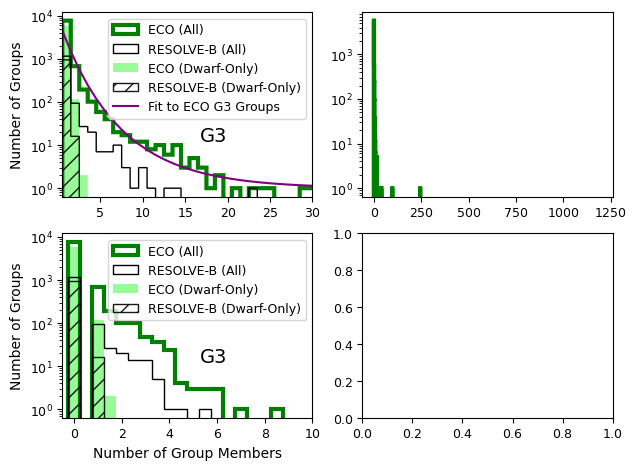

In [9]:
binv = np.arange(0.5,1200.5,1)
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
g3hist, binedges = np.histogram(g3mult,bins=binv)
bincenters=0.5*(binedges[1:]+binedges[:-1])
sel=(g3hist>0)
g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log10(g3hist[sel]))

fig, ((ax,ax2), (ax3,ax4)) = plt.subplots(figsize=(doublecolsize[0],1.2*doublecolsize[1]), ncols=2, nrows=2)
binv = np.arange(0.5,1200.5,1)
ax.hist(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax.hist(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
ax.annotate("G3",xy=(0.55,0.3),fontsize=14,xycoords='axes fraction')
ax.set_ylabel("Number of Groups")
ax.set_xlim(0.5,30)

binvd=binv
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax.hist(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False), bins=binvd, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax.legend(loc='best')
ax.set_yticks([1,10,100,1000,10000])

logbinv = np.arange(-0.25,10.5,0.5)
ax3.hist(np.log2(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False)),\
                 bins=logbinv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax3.hist(np.log2(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
ax3.set_xlabel("Number of Group Members")
ax3.annotate("G3",xy=(0.55,0.3),fontsize=14, xycoords='axes fraction')
ax3.set_ylabel("Number of Groups")
ax3.set_xlim(-0.50)

# binvd=binv
ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log2(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log2(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
#ax3.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax3.legend(loc='best')
ax3.set_xlim(-0.5,10)
# ax3.set_xticks(np.arange(0,400,40))
ax3.set_yticks([1,10,100,1000,10000])
ax3.set_xlabel("Number of Group Members")
ax3.set_ylabel("Number of Groups")


##############

ecodr2=pd.read_csv("ECODR2.csv")
ecodr2=ecodr2[ecodr2.absrmag<-17.33] 
ax2.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax2.hist(fof.multiplicity_function(np.array(resolvedata.grp_e17[(resolvedata.f_b==1)&(resolvedata.absrmag<-17.)]), return_by_galaxy=False), bins=binv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = resolvedata[(resolvedata.absrmag<-17.)&(resolvedata.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax2.hist(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False), bins=binvd, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
ax2.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax2.annotate("FoF (E17)",xy=(0.55,0.3),fontsize=14,xycoords='axes fraction')
ax2.set_xlim(0.5,30)
ax2.legend(loc='best')
ax2.set_yticks([1,10,100,1000,10000])


ax4.hist(np.log2(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False)),\
         bins=logbinv,log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
# ax4.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax4.hist(np.log2(fof.multiplicity_function(np.array(resolvedata.grp_e17[(resolvedata.f_b==1)&(resolvedata.absrmag<-17.)]), return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log2(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = resolvedata[(resolvedata.absrmag<-17.)&(resolvedata.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log2(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
# #ax4.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax4.annotate("FoF (E17)",xy=(0.55,0.3),fontsize=14, xycoords='axes fraction')
ax4.legend(loc='best')
ax4.set_xlim(-0.5,10)
#ax4.set_xticks(np.arange(0,400,40))
ax4.set_xlabel("Number of Group Members")
ax4.set_yticks([1,10,100,1000,10000])

ax.set_xlabel("Number of Group Members")
ax2.set_xlabel("Number of Group Members")
ax3.set_xlabel(r"$\log_2$(Number of Group Members)")
ax4.set_xlabel(r"$\log_2$(Number of Group Members)")

for xx in (ax,ax2,ax3,ax4):
    xx.set_ylim(0.6,1e4)
plt.tight_layout()
#plt.savefig("../figures/multfunc_doinset_newversion.pdf")
plt.show()

print("K-S test for G3 vs. FOF E17 Mult. Functions (ECO):")
fofmult=np.array(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False))
g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1]))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'less'))
print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'greater'))
print("hellinger distance: ")
g3hist,_ = np.histogram(g3mult,bins=binv,density=True)
fofhist,_ = np.histogram(fofmult,bins=binv,density=True)
print(hellinger2(g3hist,fofhist))

In [ ]:
ecodr2

/tmp/ipykernel_786233/810800823.py:16: RuntimeWarning: divide by zero encountered in log10
  g3counts = np.log10(g3counts)


[ 0.   0.5  1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5
  7.   7.5  8.   8.5  9.   9.5 10. ]


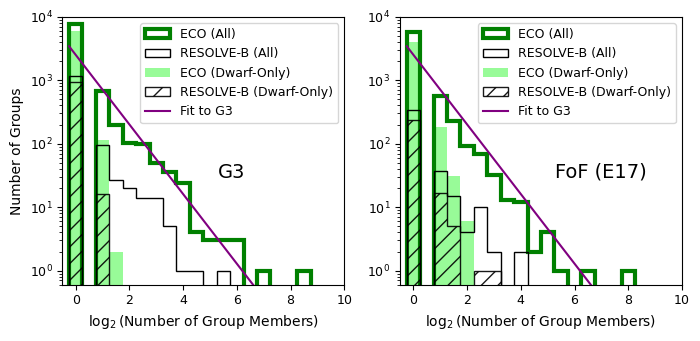

In [10]:
# binv = np.arange(0.5,1200.5,1)
# g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
# g3hist, binedges = np.histogram(g3mult,bins=binv)
# bincenters=0.5*(binedges[1:]+binedges[:-1])
# sel=(g3hist>0)
# g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log2(g3hist[sel]))

fig, (ax3,ax4) = plt.subplots(figsize=(doublecolsize[0],0.8*doublecolsize[1]), ncols=2)
logbinv = np.arange(-0.25,10.5,0.5)
g3counts, g3binedges, _ = ax3.hist(np.log2(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False)),\
                 bins=logbinv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax3.hist(np.log2(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')

# fit counts vs. bins
g3counts = np.log10(g3counts)
g3binc = 0.5*(g3binedges[1:]+g3binedges[:-1])
print(g3binc)
fitsel = (g3counts>0)
g3counts = g3counts[fitsel]
g3binc = g3binc[fitsel]
bestcoeff = np.polyfit(g3binc,g3counts,1)

ax3.annotate("G3",xy=(0.55,0.4),fontsize=14, xycoords='axes fraction')
ax3.set_ylabel("Number of Groups")
ax3.set_xlim(-0.50)

ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log2(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log2(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
#ax3.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax3.plot(logbinv,10**np.poly1d(bestcoeff)(logbinv),color='purple',label='Fit to G3')
ax3.legend(loc='best')
ax3.set_xlim(-0.5,10)
# ax3.set_xticks(np.arange(0,400,40))
ax3.set_yticks([1,10,100,1000,10000])
ax3.set_ylabel("Number of Groups")
ax3.set_xlabel(r"$\log_2$(Number of Group Members)")

##############

ecodr2=pd.read_csv("ECODR2.csv")
ecodr2=ecodr2[ecodr2.absrmag<-17.33]

rese17_=pd.read_csv("RESOLVEdata_080822.csv")

ax4.hist(np.log2(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False)),\
         bins=logbinv,log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
# ax4.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax4.hist(np.log2(fof.multiplicity_function(np.array(rese17_.grp_e17[(resolvedata.f_b==1)&(resolvedata.absrmag<-17.)]), return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log2(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = rese17_[(rese17_.absrmag<-17.)&(rese17_.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log2(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
# #ax4.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax4.annotate("FoF (E17)",xy=(0.55,0.4),fontsize=14, xycoords='axes fraction')
ax4.plot(logbinv,10**np.poly1d(bestcoeff)(logbinv),color='purple',label='Fit to G3')
ax4.legend(loc='best')
ax4.set_xlim(-0.5,10)
#ax4.set_xticks(np.arange(0,400,40))
ax4.set_xlabel(r"$\log_2$(Number of Group Members)")
ax4.set_yticks([1,10,100,1000,10000])


for xx in (ax,ax2,ax3,ax4):
    xx.set_ylim(0.6,1e4)
plt.tight_layout()
#plt.savefig("../figures/multfunc_doinset.pdf")
plt.show()

# print("K-S test for G3 vs. FOF E17 Mult. Functions (ECO):")
# fofmult=np.array(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False))
# g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1]))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'less'))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'greater'))
# print("hellinger distance: ")
# g3hist,_ = np.histogram(g3mult,bins=binv,density=True)
# fofhist,_ = np.histogram(fofmult,bins=binv,density=True)
# print(hellinger2(g3hist,fofhist))

/tmp/ipykernel_786233/279134387.py:16: RuntimeWarning: divide by zero encountered in log10
  g3counts = np.log10(g3counts)


[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2.  2.1 2.2 2.3 2.4]


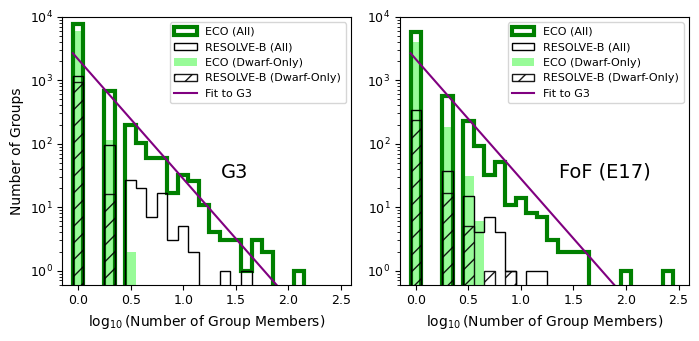

In [11]:
# binv = np.arange(0.5,1200.5,1)
# g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
# g3hist, binedges = np.histogram(g3mult,bins=binv)
# bincenters=0.5*(binedges[1:]+binedges[:-1])
# sel=(g3hist>0)
# g3popt, g3pcov = curve_fit(decayexp, bincenters[sel],np.log10(g3hist[sel]))

fig, (ax3,ax4) = plt.subplots(figsize=(doublecolsize[0],0.8*doublecolsize[1]), ncols=2)
logbinv = np.arange(-0.05,2.5,0.1)
g3counts, g3binedges, _ = ax3.hist(np.log10(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False)),\
                 bins=logbinv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax3.hist(np.log10(fof.multiplicity_function(resbg3grp[resbg3grp!=-99.], return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')

# fit counts vs. bins
g3counts = np.log10(g3counts)
g3binc = 0.5*(g3binedges[1:]+g3binedges[:-1])
print(g3binc)
fitsel = (g3counts>0)
g3counts = g3counts[fitsel]
g3binc = g3binc[fitsel]
bestcoeff = np.polyfit(g3binc,g3counts,1)

ax3.annotate("G3",xy=(0.55,0.4),fontsize=14, xycoords='axes fraction')
ax3.set_ylabel("Number of Groups")
ax3.set_xlim(-0.50)

ecodwarfonly = ecodata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log10(fof.multiplicity_function(ecodwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
resbdwarfonly = resbdata.groupby('g3grp_l').filter(lambda g: (g.absrmag>-19.5).all())
ax3.hist(np.log10(fof.multiplicity_function(resbdwarfonly.g3grp_l.to_numpy(), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', alpha=0.9, color='k', hatch='//', label='RESOLVE-B (Dwarf-Only)')
#ax3.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax3.plot(logbinv,10**np.poly1d(bestcoeff)(logbinv),color='purple',label='Fit to G3')
ax3.legend(loc='best',fontsize=8)
ax3.set_xlim(-0.15,2.6)
# ax3.set_xticks(np.arange(0,400,40))
ax3.set_yticks([1,10,100,1000,10000])
ax3.set_ylabel("Number of Groups")
ax3.set_xlabel(r"$\log_{10}$(Number of Group Members)")

##############

ecodr2=pd.read_csv("ECODR2.csv")
ecodr2=ecodr2[ecodr2.absrmag<-17.33] 
ax4.hist(np.log10(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False)),\
         bins=logbinv,log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
# ax4.hist(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False), bins=binv, log=True, label='ECO (All)', histtype='step', linewidth=3, color='green')
ax4.hist(np.log10(fof.multiplicity_function(np.array(rese17_.grp_e17[(resolvedata.f_b==1)&(resolvedata.absrmag<-17.)]), return_by_galaxy=False)),\
         bins=logbinv, log=True, label='RESOLVE-B (All)', histtype='step', color='k')
fofdwarfonly = ecodr2[(ecodr2.grp_e17!=-99.)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log10(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='stepfilled', color='palegreen', label='ECO (Dwarf-Only)')
fofdwarfonly = rese17_[(rese17_.absrmag<-17.)&(rese17_.f_b==1)].groupby('grp_e17').filter(lambda grp_e17:(grp_e17.absrmag>-19.5).all())
ax4.hist(np.log10(fof.multiplicity_function(np.array(fofdwarfonly.grp_e17), return_by_galaxy=False)),\
         bins=logbinv, log=True, histtype='step', color='k', alpha=0.9, hatch='//', label='RESOLVE-B (Dwarf-Only)')
# #ax4.plot(binv,10**decayexp(binv,*g3popt),color='purple',label='Fit to ECO G3 Groups')
ax4.annotate("FoF (E17)",xy=(0.55,0.4),fontsize=14, xycoords='axes fraction')
ax4.plot(logbinv,10**np.poly1d(bestcoeff)(logbinv),color='purple',label='Fit to G3')
ax4.legend(loc='best',fontsize=8)
ax4.set_xlim(-0.15,2.6)
#ax4.set_xticks(np.arange(0,400,40))
ax4.set_xlabel(r"$\log_{10}$(Number of Group Members)")
ax4.set_yticks([1,10,100,1000,10000])


for xx in (ax,ax2,ax3,ax4):
    xx.set_ylim(0.6,1e4)
plt.tight_layout()
plt.savefig("../figures/multfunc_doinset.pdf")
plt.show()

# print("K-S test for G3 vs. FOF E17 Mult. Functions (ECO):")
# fofmult=np.array(fof.multiplicity_function(ecodr2.grp_e17[ecodr2.grp_e17>0], return_by_galaxy=False))
# g3mult=np.array(fof.multiplicity_function(ecog3grp[ecog3grp!=-99.], return_by_galaxy=False))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1]))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'less'))
# print(kstest(g3mult[g3mult>1],fofmult[fofmult>1],'greater'))
# print("hellinger distance: ")
# g3hist,_ = np.histogram(g3mult,bins=binv,density=True)
# fofhist,_ = np.histogram(fofmult,bins=binv,density=True)
# print(hellinger2(g3hist,fofhist))

In [7]:
np.logspace(0,10,10,base=2)

array([1.00000000e+00, 2.16011948e+00, 4.66611616e+00, 1.00793684e+01,
       2.17726400e+01, 4.70315038e+01, 1.01593667e+02, 2.19454460e+02,
       4.74047853e+02, 1.02400000e+03])

In [8]:
np.log2(5)

2.321928094887362

In [9]:
1.25+0.5

1.75

In [10]:
np.log2([1,2,3,4])

array([0.       , 1.       , 1.5849625, 2.       ])

In [11]:
2-1.835+2

2.165